In [29]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/villagers.csv")
df.head()

,Name,Species,Gender,Personality,Hobby,Birthday,Catchphrase,Favorite Song,Style 1,Style 2,Color 1,Color 2,Wallpaper,Flooring,Furniture List,Filename,Unique Entry ID
0,Admiral,Bird,Male,Cranky,Nature,27-Jan,aye aye,Steep Hill,Cool,Cool,Black,Blue,dirt-clod wall,tatami,717;1849;7047;2736;787;5970;3449;3622;3802;410...,brd06,B3RyfNEqwGmcccRC3
1,Agent S,Squirrel,Female,Peppy,Fitness,2-Jul,sidekick,Go K.K. Rider,Active,Simple,Blue,Black,concrete wall,colorful tile flooring,7845;7150;3468;4080;290;3971;3449;1708;4756;25...,squ05,SGMdki6dzpDZyXAw5
2,Agnes,Pig,Female,Big Sister,Play,21-Apr,snuffle,K.K. House,Simple,Elegant,Pink,White,gray molded-panel wall,arabesque flooring,4129;7236;7235;7802;896;3428;4027;7325;3958;71...,pig17,jzWCiDPm9MqtCfecP
3,Al,Gorilla,Male,Lazy,Fitness,18-Oct,ayyyeee,Go K.K. Rider,Active,Active,Red,White,concrete wall,green rubber flooring,1452;4078;4013;833;4116;3697;7845;3307;3946;39...,gor08,LBifxETQJGEaLhBjC
4,Alfonso,Alligator,Male,Lazy,Play,9-Jun,it'sa me,Forest Life,Simple,Simple,Red,Blue,yellow playroom wall,green honeycomb tile,4763;3205;3701;1557;3623;85;3208;3584;4761;121...,crd00,REpd8KxB8p9aGBRSE


In [3]:
df.shape
df.columns.tolist()
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Name             391 non-null    str  
 1   Species          391 non-null    str  
 2   Gender           391 non-null    str  
 3   Personality      391 non-null    str  
 4   Hobby            391 non-null    str  
 5   Birthday         391 non-null    str  
 6   Catchphrase      391 non-null    str  
 7   Favorite Song    391 non-null    str  
 8   Style 1          391 non-null    str  
 9   Style 2          391 non-null    str  
 10  Color 1          391 non-null    str  
 11  Color 2          391 non-null    str  
 12  Wallpaper        391 non-null    str  
 13  Flooring         391 non-null    str  
 14  Furniture List   391 non-null    str  
 15  Filename         391 non-null    str  
 16  Unique Entry ID  391 non-null    str  
dtypes: str(17)
memory usage: 52.1 KB


,Name,Species,Gender,Personality,Hobby,Birthday,Catchphrase,Favorite Song,Style 1,Style 2,Color 1,Color 2,Wallpaper,Flooring,Furniture List,Filename,Unique Entry ID
count,391,391,391,391,391,391,391,391,391,391,391,391,391,391,391,391,391
unique,391,35,2,8,6,361,388,89,6,6,14,14,154,128,391,391,391
top,Admiral,Cat,Male,Lazy,Nature,27-Jan,bloop,Forest Life,Simple,Simple,Black,Red,backyard-fence wall,backyard lawn,717;1849;7047;2736;787;5970;3449;3622;3802;410...,brd06,B3RyfNEqwGmcccRC3
freq,1,23,204,60,66,2,2,15,118,110,47,53,13,13,1,1,1


In [4]:
print("Missing values:")
df.isnull().sum()

print("\nDuplicate rows:")
df.duplicated().sum()

Missing values:

Duplicate rows:


np.int64(0)

The dataset contains no missing values and no duplicate rows, so no rows had to be removed.

In [5]:
df["Birthday"] = pd.to_datetime(df["Birthday"], errors="coerce")
df["Birth Month"] = df["Birthday"].dt.month

df[["Birthday", "Birth Month"]].head()

/var/folders/mw/sdgy77fx2db5q5mt0f3kl8gr0000gn/T/ipykernel_95093/17687514.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Birthday"] = pd.to_datetime(df["Birthday"], errors="coerce")


,Birthday,Birth Month
0,1-01-27,1
1,1-07-02,7
2,1-04-21,4
3,1-10-18,10
4,1-06-09,6


Which species are most common?

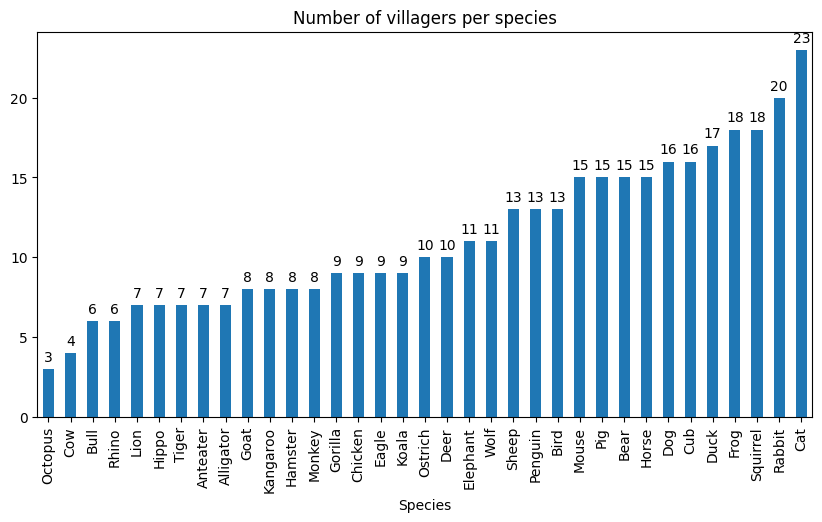

In [6]:
counts = df["Species"].value_counts().sort_values()
ax = counts.plot(kind="bar", figsize=(10,5))
plt.title("Number of villagers per species")

for i, v in enumerate(counts):
    ax.text(i, v + 0.5, str(v), ha='center')
    
plt.show()

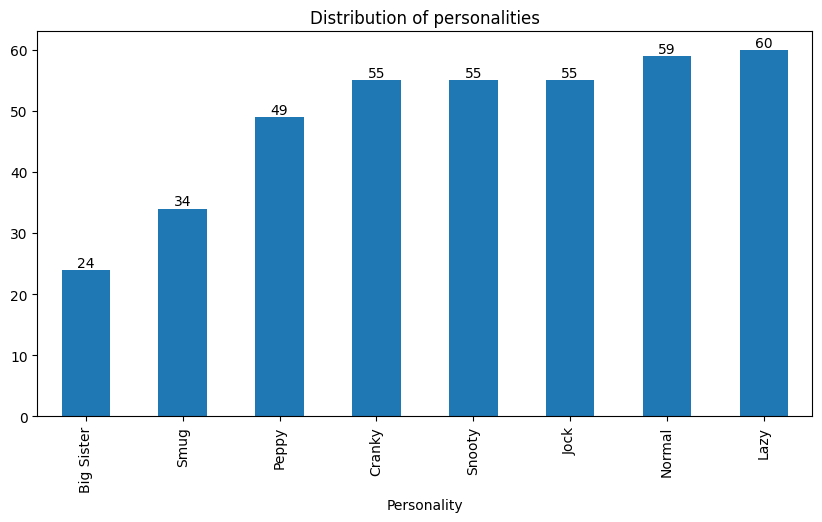

In [7]:
counts = df["Personality"].value_counts().sort_values()

ax = counts.plot(kind="bar", figsize=(10,5))
plt.title("Distribution of personalities")

for i, v in enumerate(counts):
    ax.text(i, v + 0.5, str(v), ha='center')

plt.show()

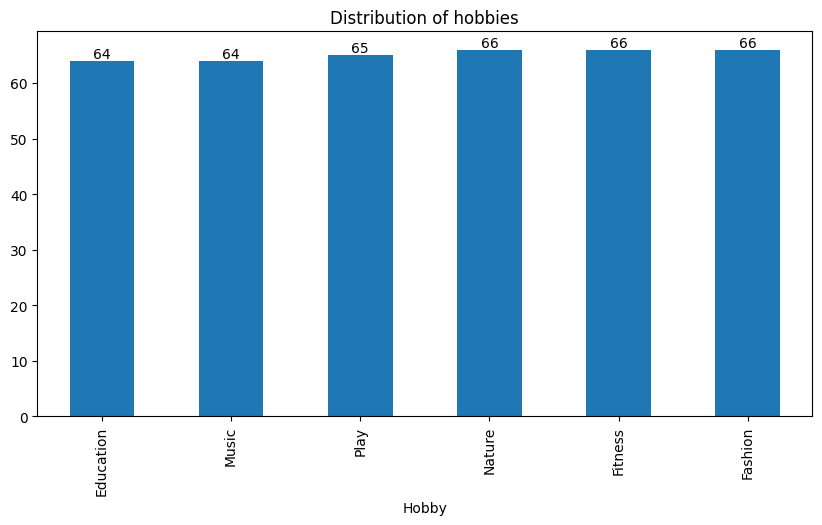

In [8]:
counts = df["Hobby"].value_counts().sort_values()

ax = counts.plot(kind="bar", figsize=(10,5))
plt.title("Distribution of hobbies")

for i, v in enumerate(counts):
    ax.text(i, v + 0.5, str(v), ha='center')

plt.show()

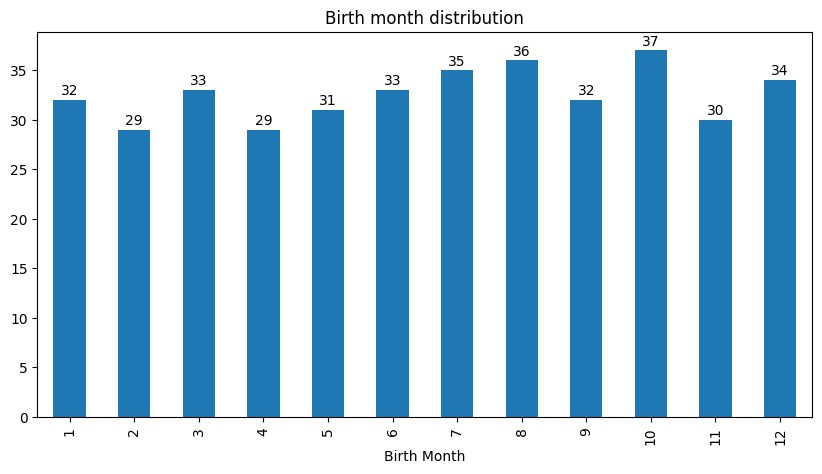

In [9]:
counts = df["Birth Month"].value_counts().sort_index()
ax = counts.plot(kind="bar", figsize=(10,5))
plt.title("Birth month distribution")

for i, v in enumerate(counts):
    ax.text(i, v + 0.5, str(v), ha='center')
    
plt.show()

In [10]:
crosstab = pd.crosstab(df["Species"], df["Personality"])
crosstab

Personality,Big Sister,Cranky,Jock,Lazy,Normal,Peppy,Smug,Snooty
Species,,,,,,,,
Alligator,0,1,2,2,1,0,0,1
Anteater,0,1,1,0,1,2,1,1
Bear,3,5,1,1,1,2,2,0
Bird,0,1,4,2,1,2,2,1
Bull,0,3,1,2,0,0,0,0
Cat,1,2,3,3,3,5,1,5
Chicken,1,1,1,2,1,0,1,2
Cow,0,0,0,0,1,1,0,2
Cub,1,2,2,4,4,2,0,1


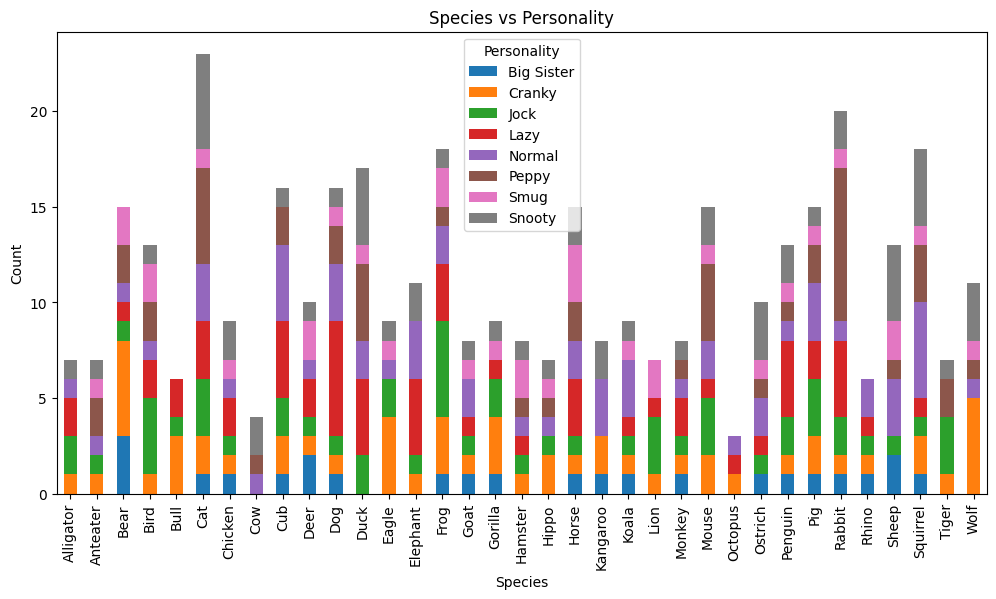

In [11]:
crosstab.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Species vs Personality")
plt.ylabel("Count")

plt.show()

In [12]:
df.groupby(["Species", "Personality"]).size().sort_values(ascending=False).head(10)

Species   Personality
Rabbit    Peppy          8
Dog       Lazy           6
Frog      Jock           5
Wolf      Cranky         5
Cat       Snooty         5
          Peppy          5
Bear      Cranky         5
Squirrel  Normal         5
Mouse     Peppy          4
Rabbit    Lazy           4
dtype: int64

In [13]:
df_encoded = pd.get_dummies(df[["Species", "Personality", "Hobby"]])
corr = df_encoded.corr()
corr

,Species_Alligator,Species_Anteater,Species_Bear,Species_Bird,Species_Bull,Species_Cat,Species_Chicken,Species_Cow,Species_Cub,Species_Deer,...,Personality_Normal,Personality_Peppy,Personality_Smug,Personality_Snooty,Hobby_Education,Hobby_Fashion,Hobby_Fitness,Hobby_Music,Hobby_Nature,Hobby_Play
Species_Alligator,1.000000,-0.018229,-0.026967,-0.025039,-0.016855,-0.033754,-0.020724,-0.013726,-0.027889,-0.021874,...,-0.003032,-0.051106,-0.041667,0.000851,-0.059731,-0.009350,-0.009350,-0.059731,0.042143,0.095136
Species_Anteater,-0.018229,1.000000,-0.026967,-0.025039,-0.016855,-0.033754,-0.020724,-0.013726,-0.027889,-0.021874,...,-0.003032,0.065409,0.026786,0.000851,0.096663,0.042143,-0.009350,-0.059731,-0.009350,-0.060288
Species_Bear,-0.026967,-0.026967,1.000000,-0.037041,-0.024934,-0.049933,-0.030658,-0.020306,-0.041257,-0.032359,...,-0.046999,0.004834,0.032874,-0.080810,0.019605,-0.018911,0.052187,-0.016384,0.016638,-0.053420
Species_Bird,-0.025039,-0.025039,-0.037041,1.000000,-0.023151,-0.046362,-0.028465,-0.018854,-0.038306,-0.030044,...,-0.038324,0.015979,0.044024,-0.034000,-0.043487,-0.007403,0.030682,-0.043487,-0.007403,0.070461
Species_Bull,-0.016855,-0.016855,-0.024934,-0.023151,1.000000,-0.031209,-0.019162,-0.012692,-0.025786,-0.020225,...,-0.052626,-0.047253,-0.038526,-0.050508,0.001007,-0.056257,0.165929,-0.055228,-0.000710,-0.055743
Species_Cat,-0.033754,-0.033754,-0.049933,-0.046362,-0.031209,1.000000,-0.038373,-0.025416,-0.051640,-0.040502,...,-0.014290,0.069523,-0.038576,0.055171,-0.022466,0.032432,-0.054623,0.095047,-0.054623,0.005152
Species_Chicken,-0.020724,-0.020724,-0.030658,-0.028465,-0.019162,-0.038373,1.000000,-0.015605,-0.031705,-0.024867,...,-0.017060,-0.058100,0.013158,0.036006,0.024286,-0.069170,-0.023639,0.070381,-0.069170,0.068890
Species_Cow,-0.013726,-0.013726,-0.020306,-0.018854,-0.012692,-0.025416,-0.015605,1.000000,-0.021000,-0.016471,...,0.028148,0.038286,-0.031375,0.105075,-0.044977,0.157748,-0.045815,-0.044977,0.022040,-0.045397
Species_Cub,-0.027889,-0.027889,-0.041257,-0.038306,-0.025786,-0.051640,-0.031705,-0.021000,1.000000,-0.033464,...,0.057190,-0.000199,-0.063746,-0.046439,-0.021596,-0.024152,-0.024152,-0.056489,0.010313,0.115825
Species_Deer,-0.021874,-0.021874,-0.032359,-0.030044,-0.020225,-0.040502,-0.024867,-0.016471,-0.033464,1.000000,...,-0.023035,-0.061323,0.064996,-0.018949,0.015902,-0.073008,-0.073008,0.015902,0.099998,0.014691


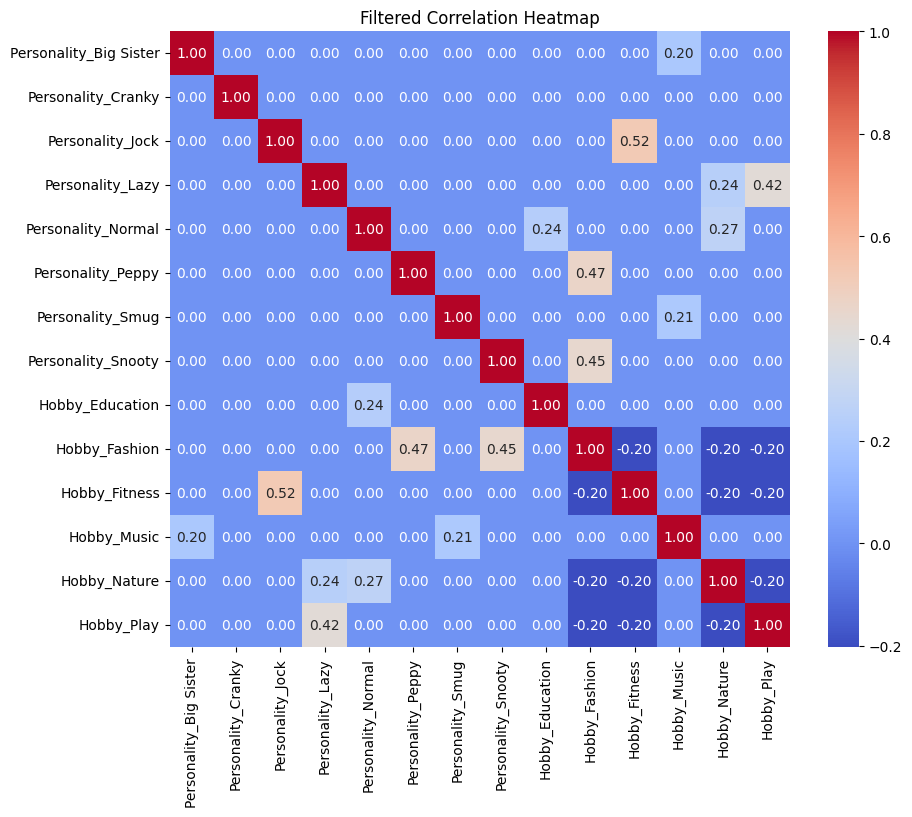

In [27]:
corr = pd.get_dummies(df[["Personality", "Hobby"]]).corr()

# Stronger connection, but fill the rest with zeros for better visualization
filtered = corr.where((corr > 0.2) | (corr < -0.2), 0)

plt.figure(figsize=(10,8))
sns.heatmap(filtered, cmap="coolwarm", annot=True, fmt=".2f")

plt.title("Filtered Correlation Heatmap")
plt.show()

Since the dataset is mostly categorical, I converted selected columns into dummy variables in order to examine correlations visually.

The full heatmap became too dense and difficult to interpret, so I focused on the most relevant variables to make the relationships clearer.

Weak correlations were replaced with zero in the filtered heatmap to make the strongest relationships easier to read.

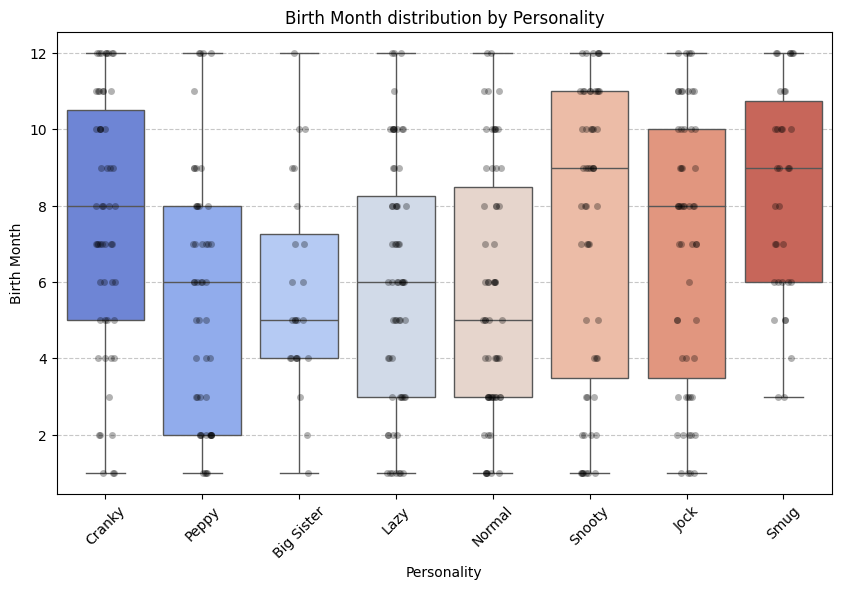

In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Personality", y="Birth Month", data=df, hue="Personality", palette="coolwarm")

sns.stripplot(x="Personality", y="Birth Month", data=df, color="black", alpha=0.3)

plt.title("Birth Month distribution by Personality")
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

The dataset does not show strong outliers, which indicates that the birth months are fairly evenly distributed.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# We want to predict 'Hobby' based on 'Personality'
le_pers = LabelEncoder()
le_hobby = LabelEncoder()

df['Pers_Encoded'] = le_pers.fit_transform(df['Personality'])
df['Hobby_Encoded'] = le_hobby.fit_transform(df['Hobby'])

X = df[['Pers_Encoded']] # Predictor
y = df['Hobby_Encoded']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print(f"Model Accuracy: {model.score(X_test, y_test):.2f}")

Model Accuracy: 0.51


Conclusions:

- The dataset contains 391 villagers and 17 columns.
- There are no missing values or duplicates.
- Some species appear more frequently than others.
- Hobbies are relatively evenly distributed.
- There are visible relationships between species and personality.
- Birth months are spread across the year without strong peaks.

Overall, the dataset shows clear patterns in villager characteristics.

In [17]:
# Dataset size check (requirement: at least ~2000 cells)

rows, cols = df.shape
print(f"Rows: {rows}")
print(f"Columns: {cols}")
print(f"Total cells: {rows * cols}")

if rows * cols < 2000:
    print("Warning: Dataset is smaller than the required size.")
else:
    print("Dataset meets the minimum size requirement.")

Rows: 391
Columns: 18
Total cells: 7038
Dataset meets the minimum size requirement.
